# Mental Health Support Pipeline

**Complete integrated pipeline testing all three modules:**
1. Crisis Detection (keyword-based)
2. Module 1: Language Detection (TF-IDF)
3. Module 3: Intent Classification + LLM (Groq)
4. Module 2: Emotion Detection (Mental-RoBERTa)
5. Module 4: RAG Retrieval (placeholder)
6. LLM Synthesis (Groq)
7. Post-Guardrails (hallucination check)
8. Response to user

## Section 0: Setup & Imports

In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import joblib
from dotenv import load_dotenv
from pathlib import Path

# Deep Learning
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# LLM
from groq import Groq

# Utils
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful")
print(f"PyTorch device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✅ All imports successful
PyTorch device: cuda


## Section 1: Configure Paths & Initialize Clients

In [5]:
# Setup paths
BASE_DIR = Path(os.getcwd()).parent
MODULE1_PATH = BASE_DIR / "Module 1"
MODULE2_PATH = BASE_DIR / "Module 2"
MODULE3_PATH = BASE_DIR / "Module 3"
MODULE4_PATH = BASE_DIR / "Module 4"

MODEL1_DIR = MODULE1_PATH / "models"
MODEL2_DIR = MODULE2_PATH / "models"

print(f"Module 1 path: {MODULE1_PATH}")
print(f"Module 2 path: {MODULE2_PATH}")
print(f"Model 1 path: {MODEL1_DIR}")
print(f"Model 2 path: {MODEL2_DIR}")

# Initialize Groq client
load_dotenv()
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
if not GROQ_API_KEY:
    raise ValueError('GROQ_API_KEY not found in environment')

GROQ_MODEL = 'llama-3.3-70b-versatile'
groq_client = Groq(api_key=GROQ_API_KEY)
print(f"✅ Groq client initialized | Model: {GROQ_MODEL}")

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

Module 1 path: d:\Python\saqr_draft\Module 1
Module 2 path: d:\Python\saqr_draft\Module 2
Model 1 path: d:\Python\saqr_draft\Module 1\models
Model 2 path: d:\Python\saqr_draft\Module 2\models
✅ Groq client initialized | Model: llama-3.3-70b-versatile
✅ Using device: cuda


## Section 2: Module 1 - Language Detection

In [24]:
# Load Module 1 models
tfidf_vectorizer = joblib.load(MODEL1_DIR / "tfidf_vectorizer.pkl")
language_classifier = joblib.load(MODEL1_DIR / "language_classifier.pkl")

# Language ID to label mapping (20 languages)
LANGUAGE_MAP = {
    0: 'ar', 1: 'bg', 2: 'de', 3: 'el', 4: 'en',
    5: 'es', 6: 'fr', 7: 'hi', 8: 'it', 9: 'ja',
    10: 'nl', 11: 'pl', 12: 'pt', 13: 'ru', 14: 'sw',
    15: 'th', 16: 'tr', 17: 'ur', 18: 'vi', 19: 'zh'
}
REVERSE_LANGUAGE_MAP = {v: k for k, v in LANGUAGE_MAP.items()}

def detect_language(text):
    if not text or not isinstance(text, str):
        return 'en', 0.0
    
    text_clean = text.strip().lower()
    tfidf_features = tfidf_vectorizer.transform([text_clean])
    
    # If the model natively outputs string labels:
    language = language_classifier.predict(tfidf_features)[0]
    
    probabilities = language_classifier.predict_proba(tfidf_features)[0]
    confidence = float(np.max(probabilities))
    
    return language, confidence

# Test Module 1
test_texts = [
    "Hello, how are you?",
    "Bonjour, comment allez-vous?",
    "¿Hola, cómo estás?",
    "مرحبا، كيف حالك؟"
]

print("Module 1 - Language Detection Test:")
for text in test_texts:
    lang, conf = detect_language(text)
    print(f"  '{text[:30]}...' → {lang} ({conf:.2%})")

Module 1 - Language Detection Test:
  'Hello, how are you?...' → en (93.80%)
  'Bonjour, comment allez-vous?...' → fr (92.05%)
  '¿Hola, cómo estás?...' → es (89.72%)
  'مرحبا، كيف حالك؟...' → ar (62.90%)


## Section 3: Module 2 - Emotion Detection

In [7]:
# Load Module 2 models
MODEL_NAME = "mental/mental-roberta-base"
emotion_tokenizer = AutoTokenizer.from_pretrained(str(MODEL2_DIR / "emotion_classifier"))
emotion_model = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL2_DIR / "emotion_classifier")
).to(device)
emotion_model.eval()

# Emotion labels
ID2EMOTION = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

def detect_emotion(text, max_len=128):
    """Module 2: Detect emotion from text using Mental-RoBERTa"""
    if not text or not isinstance(text, str):
        return "neutral", 0.0, {}
    
    encoded = emotion_tokenizer(
        text,
        max_length=max_len,
        truncation=True,
        padding="max_length",
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        outputs = emotion_model(**encoded)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
    
    emotion_id = np.argmax(probabilities)
    emotion = ID2EMOTION.get(emotion_id, "unknown")
    confidence = float(probabilities[emotion_id])
    
    # Determine distress level
    is_high_distress = emotion in ["sadness", "anger", "fear"] and confidence > 0.6
    
    emotion_scores = {ID2EMOTION.get(i, "unknown"): float(p) for i, p in enumerate(probabilities)}
    
    return emotion, confidence, emotion_scores, is_high_distress

print("✅ Module 2 (Emotion Classifier) loaded successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Module 2 (Emotion Classifier) loaded successfully


## Section 4: Module 3 - Intent Classification & Crisis Detection

In [8]:
# Module 3: Crisis Detection Keywords
CRISIS_KEYWORDS = [
    'kill myself', 'end my life', 'want to die', 'suicide', 'suicidal',
    'hurt myself', 'self harm', 'self-harm', 'cutting myself',
    'want to hurt myself', 'no reason to live', 'better off dead',
    'overdose', 'jump off', 'hang myself',
    'أريد الموت', 'انتحار', 'أؤذي نفسي', 'أقتل نفسي', 'لا أريد العيش',
    'me suicider', 'me tuer', 'mettre fin à ma vie',
    'mich umbringen', 'suizid', 'selbstmord',
    'suicidarme', 'matarme', 'quiero morir',
]

CRISIS_RESPONSE = (
    "🆘 I'm really concerned about what you've shared. You're not alone.\n\n"
    "Please contact a crisis helpline immediately (available 24/7):\n"
    "🌍 International Association for Suicide Prevention: https://www.iasp.info/resources/Crisis_Centres/\n"
    "🤝 Crisis Text Line (US): Text HOME to 741741\n"
    "🌐 Befrienders Worldwide: https://www.befrienders.org\n\n"
    "Your life matters. Please reach out to someone right now."
)

def check_crisis(text):
    """Step 0: Check for crisis keywords"""
    text_lower = text.lower()
    return any(kw in text_lower for kw in CRISIS_KEYWORDS)

# Module 3: Regex Intent Matcher
KEYWORD_PATTERNS = {
    'greeting': [r'\bhi\b', r'\bhello\b', r'\bhey\b', r'\bgood morning\b',
                 r'\bgood evening\b', r'\bgood afternoon\b', r'\bhow are you\b',
                 r'\bhowdy\b', r'\bgreetings\b'],
    'goodbye':  [r'\bbye\b', r'\bgoodbye\b', r'\bfarewell\b', r'\bsee you\b',
                 r'\btake care\b', r'\bgoodnight\b', r'\bi have to go\b',
                 r'\bi need to go\b', r'\btalk to you later\b', r'\bcatch you later\b'],
    'gratitude': [r'\bthank you\b', r'\bthanks\b', r'\bthank u\b',
                  r'\bi appreciate\b', r'\bgrateful\b', r'\bmany thanks\b']
}

def regex_match(text):
    """Layer 1: Try to match using regex (fast, zero API cost)"""
    text_lower = text.lower().strip()
    if len(text_lower.split()) > 4:
        return None
    for intent, patterns in KEYWORD_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, text_lower):
                return intent
    return None

print("✅ Module 3 (Intent & Crisis Detection) setup complete")

✅ Module 3 (Intent & Crisis Detection) setup complete


## Section 5: Module 3 - LLM Intent Classification

In [9]:
INTENTS = ['greeting', 'goodbye', 'gratitude', 'asking_mental_health_question', 'out_of_scope']
LLM_CONFIDENCE_THRESHOLD = 0.50

COMBINED_SYSTEM_PROMPT = """You are an assistant for a multilingual mental health support chatbot.
Analyze the user message and return a JSON object with exactly these 4 fields:

1. "intent": Classify into exactly one of:
   - greeting
   - goodbye
   - gratitude
   - asking_mental_health_question
   - out_of_scope

2. "translated": The message in clean English.
   - If non-English: translate it. Preserve exact emotional tone and urgency. NEVER soften distress.
   - If already English: return as-is but fix typos and grammar. Never change the meaning.

3. "language": The TRUE language ISO code (en, ar, fr, de, es, it, pt, ru, zh, ja, tr, hi, nl, pl, bg, el, sw, vi, ur, th).
   - You receive a hint from our detector — treat it as suggestion only.
   - Use your own judgment, especially for short text where detectors fail.
   - If ambiguous (e.g. single word like "hi"), default to "en".

4. "confidence": Float 0-1 for intent certainty.

Return ONLY valid JSON:
{"intent": "...", "translated": "...", "language": "...", "confidence": 0.0}

Examples:
Message: "Hi" | hint: "zh" -> {"intent": "greeting", "translated": "Hi", "language": "en", "confidence": 0.99}
Message: "أشعر بالقلق الشديد ولا أستطيع النوم" | hint: "ar" -> {"intent": "asking_mental_health_question", "translated": "I feel very anxious and cannot sleep", "language": "ar", "confidence": 0.98}
Message: "Je me sens très triste et seul" | hint: "sw" -> {"intent": "asking_mental_health_question", "translated": "I feel very sad and lonely", "language": "fr", "confidence": 0.97}
Message: "i cant stpo crying and i dont knwo wat to do" | hint: "en" -> {"intent": "asking_mental_health_question", "translated": "I can't stop crying and I don't know what to do", "language": "en", "confidence": 0.98}
Message: "مع السلامة" | hint: "ar" -> {"intent": "goodbye", "translated": "Goodbye", "language": "ar", "confidence": 0.99}
Message: "What is the weather today?" | hint: "en" -> {"intent": "out_of_scope", "translated": "What is the weather today?", "language": "en", "confidence": 0.99}
Message: "I said goodbye to my old bad habits" | hint: "en" -> {"intent": "asking_mental_health_question", "translated": "I said goodbye to my old bad habits", "language": "en", "confidence": 0.95}
"""

def analyze_message_llm(text, language_hint, max_retries=3):
    """Layer 2: Single Groq call — 4 jobs in one:
    1. Verify/correct language (hint from Module 1)
    2. Classify intent
    3. Translate to English (if non-English)
    4. Clean typos/grammar (if English)
    """
    for attempt in range(max_retries):
        try:
            response = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[
                    {'role': 'system', 'content': COMBINED_SYSTEM_PROMPT},
                    {'role': 'user', 'content': f'Message: "{text}" | hint: "{language_hint}"'}
                ],
                temperature=0.0,
                max_tokens=200
            )
            raw = response.choices[0].message.content.strip()
            raw = re.sub(r'```json|```', '', raw).strip()
            parsed = json.loads(raw)
            
            if parsed.get('intent') not in INTENTS:
                raise ValueError(f"Invalid intent: {parsed.get('intent')}")
            
            return {
                'intent': parsed['intent'],
                'translated': parsed.get('translated', text),
                'language': parsed.get('language', language_hint),
                'confidence': float(parsed.get('confidence', 0.5)),
                'layer_used': 'Layer 2 (LLM)'
            }
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"  ⚠️ LLM failed after {max_retries} attempts: {str(e)[:50]}")
                return {
                    'intent': 'out_of_scope',
                    'translated': text,
                    'language': language_hint,
                    'confidence': 0.0,
                    'layer_used': 'Layer 2 (LLM — fallback)'
                }

def classify_intent(text, language_hint='en'):
    """Unified classifier: try Regex first, then LLM.
    Returns consistent dictionary structure.
    """
    # Try regex first (fast, zero cost)
    regex_result = regex_match(text)
    if regex_result:
        return {
            'intent': regex_result,
            'translated': text,
            'language': language_hint,
            'confidence': 1.0,
            'layer_used': 'Layer 1 (Regex)'
        }
    
    # Fall back to LLM
    return analyze_message_llm(text, language_hint)

print("✅ Module 3 (LLM Intent Classification) setup complete")

✅ Module 3 (LLM Intent Classification) setup complete


## Section 6: Module 4 - RAG Retrieval (Placeholder)

In [10]:
def retrieve_rag_chunks(query, k=3):
    """Module 4: RAG Retrieval
    
    For now, returns placeholder chunks.
    In production, this would:
    1. Embed the cleaned/translated query
    2. Retrieve top-k chunks from vector DB
    3. Return ranked chunks with relevance scores
    """
    placeholder_chunks = [
        {
            'id': 0,
            'content': 'Anxiety is a common mental health condition characterized by persistent worry and fear. It can be managed through cognitive behavioral therapy (CBT), mindfulness, and in some cases, medication.',
            'relevance': 0.95,
            'source': 'Knowledge_Base_1'
        },
        {
            'id': 1,
            'content': 'Deep breathing exercises can help reduce anxiety symptoms. Try the 4-7-8 technique: breathe in for 4 counts, hold for 7, exhale for 8.',
            'relevance': 0.87,
            'source': 'Knowledge_Base_2'
        },
        {
            'id': 2,
            'content': 'Regular exercise, adequate sleep, and social support are fundamental pillars of mental health wellness.',
            'relevance': 0.82,
            'source': 'Knowledge_Base_3'
        }
    ]
    return placeholder_chunks[:k]

print("✅ Module 4 (RAG Placeholder) setup complete")

✅ Module 4 (RAG Placeholder) setup complete


## Section 7: Direct Responses (for greeting/goodbye/gratitude)

In [11]:
DIRECT_RESPONSES = {
    'greeting': {
        'en': ["Hello! I'm here to support you. How are you feeling today?",
               "Hi there! I'm your mental health support assistant. What's on your mind?"],
        'ar': ["مرحباً! أنا هنا لدعمك. كيف تشعر اليوم؟"],
        'fr': ["Bonjour! Je suis là pour vous soutenir. Comment vous sentez-vous aujourd'hui?"],
        'de': ["Hallo! Ich bin hier um Sie zu unterstützen. Wie fühlen Sie sich heute?"],
        'es': ["¡Hola! Estoy aquí para apoyarte. ¿Cómo te sientes hoy?"],
        'it': ["Ciao! Sono qui per supportarti. Come ti senti oggi?"],
        'pt': ["Olá! Estou aqui para te apoiar. Como você está se sentindo hoje?"],
        'default': ["Hello! I'm here to support you. How are you feeling today?"]
    },
    'goodbye': {
        'en': ["Take care of yourself. Support is always here when you need it.",
               "Goodbye! I hope our conversation was helpful. Be well."],
        'ar': ["اعتنِ بنفسك. الدعم دائماً هنا عندما تحتاجه."],
        'fr': ["Prenez soin de vous. Le soutien est toujours là."],
        'default': ["Take care of yourself. Support is always here when you need it."]
    },
    'gratitude': {
        'en': ["You're very welcome. I'm always here for you.",
               "I'm glad I could help. Please reach out anytime."],
        'ar': ["على الرحب والسعة. أنا دائماً هنا من أجلك."],
        'fr': ["De rien. Je suis toujours là pour vous."],
        'default': ["You're very welcome. I'm always here for you."]
    }
}

OUT_OF_SCOPE_RESPONSES = {
    'en': "I'm specialized in mental health support. Is there anything related to your emotional wellbeing I can help with?",
    'ar': "أنا متخصص في دعم الصحة النفسية. هل هناك شيء يتعلق بصحتك النفسية يمكنني مساعدتك به؟",
    'fr': "Je suis spécialisé dans le soutien en santé mentale. Y a-t-il quelque chose lié à votre bien-être émotionnel?",
    'default': "I'm specialized in mental health support. Is there anything related to your emotional wellbeing I can help with?"
}

def get_direct_response(intent, language):
    """Get predefined response for greeting/goodbye/gratitude"""
    options = DIRECT_RESPONSES[intent].get(language, DIRECT_RESPONSES[intent]['default'])
    return random.choice(options)

def get_out_of_scope_response(language):
    """Get predefined response for out-of-scope queries"""
    return OUT_OF_SCOPE_RESPONSES.get(language, OUT_OF_SCOPE_RESPONSES['default'])

print("✅ Direct responses setup complete")

✅ Direct responses setup complete


## Section 8: LLM Synthesis

In [12]:
def synthesize_response(cleaned_text, emotion, distress_level, rag_chunks, verified_language):
    """Step 6: LLM Synthesis
    
    Uses:
    - cleaned/translated English text (from Module 3 LLM)
    - emotion + distress level (from Module 2)
    - retrieved RAG chunks (from Module 4)
    - verified user language (from Module 3 LLM)
    
    Returns response in user's verified language
    """
    chunks_text = "\n".join([f"- {c['content']}" for c in rag_chunks])
    
    synthesis_prompt = f"""You are a compassionate mental health support assistant.

User's Cleaned Message: {cleaned_text}
Detected Emotion: {emotion}
Distress Level: {'HIGH' if distress_level else 'NORMAL'}

Available Knowledge Base Chunks:
{chunks_text}

Generate a warm, empathetic response that:
1. Acknowledges their emotion
2. Incorporates relevant knowledge from the chunks
3. Offers actionable advice if appropriate
4. Maintains a supportive, non-judgmental tone
5. Responds in their language: {verified_language}

Keep response concise (2-3 sentences) but meaningful.
"""
    
    try:
        response = groq_client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[{'role': 'user', 'content': synthesis_prompt}],
            temperature=0.7,
            max_tokens=300
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"  ⚠️ Synthesis failed: {str(e)[:50]}")
        return "I understand your concerns. Please know that support is available, and you're not alone in this."

print("✅ LLM Synthesis setup complete")

✅ LLM Synthesis setup complete


## Section 9: Post-Guardrails (Hallucination Check)

In [13]:
def check_hallucination(user_text, generated_response):
    """Step 7: Post-Guardrails - Check for hallucinations
    
    Ensures the response doesn't make claims about the user
    that weren't mentioned or contradict established facts.
    """
    hallucination_flags = []
    
    # Check if response attributes feelings to user that weren't mentioned
    false_attributions = [
        ('you are depressed', user_text, 'depression'),
        ('you have anxiety', user_text, 'anxiety'),
        ('you are suicidal', user_text, 'suicide'),
    ]
    
    for phrase, text, condition in false_attributions:
        if phrase.lower() in generated_response.lower():
            if condition.lower() not in text.lower():
                hallucination_flags.append(f"Potential false attribution: '{phrase}'")
    
    # Check for suspicious medical claims
    suspicious_claims = ['you are cured', 'you will be fine in', 'this will definitely solve']
    for claim in suspicious_claims:
        if claim.lower() in generated_response.lower():
            hallucination_flags.append(f"Suspicious medical claim: '{claim}'")
    
    return {
        'is_hallucinated': len(hallucination_flags) > 0,
        'flags': hallucination_flags
    }

print("✅ Post-Guardrails setup complete")

✅ Post-Guardrails setup complete


## Section 10: Complete Pipeline Router

In [17]:
def pipeline(user_query, verbose=True):
    """Complete Mental Health Support Pipeline
    
    Flow:
    1. Crisis Detection (local, keyword-based, zero API cost)
    2. Module 1: Language Detection (local, TF-IDF)
    3. Module 3: Intent Classification + LLM (Groq)
    4. Module 2: Emotion Detection (local, Mental-RoBERTa)
    5. Module 4: RAG Retrieval (local placeholder)
    6. LLM Synthesis (Groq)
    7. Post-Guardrails (hallucination check)
    8. Response to user
    
    Returns: Complete result dictionary
    """
    result = {
        'user_query': user_query,
        'pipeline_steps': {},
        'final_response': None,
        'route': None
    }
    
    if verbose:
        print(f"\n🔄 PIPELINE START | Input: '{user_query}'\n")
    
    # ════════════════════════════════════════════════════════════════════════════════════════
    # Step 0: Crisis Detection
    # ════════════════════════════════════════════════════════════════════════════════════════
    if verbose:
        print("Step 0️⃣  CRISIS DETECTION")
    is_crisis = check_crisis(user_query)
    result['pipeline_steps']['crisis_check'] = {
        'is_crisis': is_crisis,
        'status': '🚨 CRISIS DETECTED' if is_crisis else '✅ Safe'
    }
    if verbose:
        print(f"        Status: {result['pipeline_steps']['crisis_check']['status']}")
    
    if is_crisis:
        result['route'] = 'crisis'
        result['final_response'] = CRISIS_RESPONSE
        if verbose:
            print(f"\n⚠️  CRISIS DETECTED - Returning emergency response\n")
        return result
    
    # ════════════════════════════════════════════════════════════════════════════════════════
    # Step 1: Module 1 - Language Detection
    # ════════════════════════════════════════════════════════════════════════════════════════
    if verbose:
        print("\nStep 1️⃣  MODULE 1: LANGUAGE DETECTION")
    language, lang_confidence = detect_language(user_query)
    result['pipeline_steps']['language_detection'] = {
        'detected_language': language,
        'confidence': lang_confidence
    }
    if verbose:
        print(f"        Detected: {language} ({lang_confidence:.1%})")
    
    # ════════════════════════════════════════════════════════════════════════════════════════
    # Step 2-4: Module 3 - Intent Classification + LLM
    # ════════════════════════════════════════════════════════════════════════════════════════
    if verbose:
        print("\nStep 2️⃣  MODULE 3: INTENT CLASSIFICATION (Regex + LLM)")
    intent_result = classify_intent(user_query, language)
    result['pipeline_steps']['intent_classification'] = intent_result
    if verbose:
        print(f"        Intent: {intent_result['intent']}")
        print(f"        Layer used: {intent_result['layer_used']}")
        print(f"        Confidence: {intent_result['confidence']:.1%}")
        print(f"        Translated: '{intent_result['translated'][:60]}...'")
    
    intent = intent_result['intent']
    translated_text = intent_result['translated']
    verified_language = intent_result['language']
    intent_confidence = intent_result['confidence']
    
    # Check confidence threshold
    if intent_confidence < LLM_CONFIDENCE_THRESHOLD:
        if verbose:
            print(f"\n⚠️  LOW CONFIDENCE ({intent_confidence:.1%}) - Requesting clarification\n")
        result['route'] = 'clarification'
        result['final_response'] = "I want to make sure I understand you correctly. Could you rephrase that?"
        return result
    
    # ════════════════════════════════════════════════════════════════════════════════════════
    # Route Based on Intent
    # ════════════════════════════════════════════════════════════════════════════════════════
    
    # A: Direct responses (greeting, goodbye, gratitude)
    if intent in ('greeting', 'goodbye', 'gratitude'):
        if verbose:
            print(f"\n➡️  ROUTE: Direct Response ({intent})")
        result['route'] = 'direct'
        response = get_direct_response(intent, verified_language)
        result['final_response'] = response
        if verbose:
            print(f"   Response: {response}\n")
        return result
    
    # B: Out-of-scope
    elif intent == 'out_of_scope':
        if verbose:
            print(f"\n➡️  ROUTE: Out-of-Scope")
        result['route'] = 'out_of_scope'
        response = get_out_of_scope_response(verified_language)
        result['final_response'] = response
        if verbose:
            print(f"   Response: {response}\n")
        return result
    
    # C: Mental health question → Full RAG pipeline
    else:  # asking_mental_health_question
        if verbose:
            print(f"\n➡️  ROUTE: Mental Health Question (Full RAG Pipeline)")
        result['route'] = 'rag_pipeline'
        
        # ════════════════════════════════════════════════════════════════════════════════════════
        # Step 3: Module 2 - Emotion Detection
        # ════════════════════════════════════════════════════════════════════════════════════════
        if verbose:
            print("\nStep 3️⃣  MODULE 2: EMOTION DETECTION")
        emotion, emotion_conf, emotion_scores, is_distress = detect_emotion(translated_text)
        result['pipeline_steps']['emotion_detection'] = {
            'emotion': emotion,
            'confidence': emotion_conf,
            'is_high_distress': is_distress,
            'emotion_scores': emotion_scores
        }
        if verbose:
            print(f"        Emotion: {emotion} ({emotion_conf:.1%})")
            print(f"        High distress: {is_distress}")
            print(f"        All scores: {', '.join([f'{e}={s:.2f}' for e, s in emotion_scores.items()])}")
        
        # ════════════════════════════════════════════════════════════════════════════════════════
        # Step 4: Module 4 - RAG Retrieval
        # ════════════════════════════════════════════════════════════════════════════════════════
        if verbose:
            print("\nStep 4️⃣  MODULE 4: RAG RETRIEVAL")
        rag_chunks = retrieve_rag_chunks(translated_text, k=3)
        result['pipeline_steps']['rag_retrieval'] = {
            'query': translated_text,
            'chunks_retrieved': len(rag_chunks),
            'chunks': rag_chunks
        }
        if verbose:
            print(f"        Retrieved {len(rag_chunks)} chunks")
            for i, chunk in enumerate(rag_chunks, 1):
                print(f"          [{i}] ({chunk['relevance']:.2f}) {chunk['content'][:50]}...")
        
        # ════════════════════════════════════════════════════════════════════════════════════════
        # Step 5: LLM Synthesis
        # ════════════════════════════════════════════════════════════════════════════════════════
        if verbose:
            print("\nStep 5️⃣  LLM SYNTHESIS")
        synthesized_response = synthesize_response(
            translated_text,
            emotion,
            is_distress,
            rag_chunks,
            verified_language
        )
        result['pipeline_steps']['llm_synthesis'] = {
            'raw_response': synthesized_response
        }
        if verbose:
            print(f"        Generated: {synthesized_response[:80]}...")
        
        # ════════════════════════════════════════════════════════════════════════════════════════
        # Step 6: Post-Guardrails
        # ════════════════════════════════════════════════════════════════════════════════════════
        if verbose:
            print("\nStep 6️⃣  POST-GUARDRAILS (Hallucination Check)")
        guardrail_result = check_hallucination(user_query, synthesized_response)
        result['pipeline_steps']['post_guardrails'] = guardrail_result
        if verbose:
            if guardrail_result['is_hallucinated']:
                print(f"        ⚠️  Hallucinations detected: {guardrail_result['flags']}")
            else:
                print(f"        ✅ No hallucinations detected")
        
        # ════════════════════════════════════════════════════════════════════════════════════════
        # Final Response
        # ════════════════════════════════════════════════════════════════════════════════════════
        result['final_response'] = synthesized_response
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"🎯 FINAL RESPONSE ({verified_language}):")
            print(f"{'='*80}")
            print(f"{synthesized_response}")
            print(f"{'='*80}\n")
        
        return result

print("✅ Complete Pipeline defined")

✅ Complete Pipeline defined


## Section 11: Test Cases

In [18]:
# Define test cases
test_cases = [
    {
        'query': 'Hello! How are you today?',
        'description': 'Simple greeting',
        'expected_route': 'direct'
    },
    {
        'query': 'I feel very anxious and can\'t sleep',
        'description': 'Mental health question (English)',
        'expected_route': 'rag_pipeline'
    },
    {
        'query': 'Thank you so much for your help',
        'description': 'Gratitude expression',
        'expected_route': 'direct'
    },
    {
        'query': 'Goodbye, take care',
        'description': 'Goodbye message',
        'expected_route': 'direct'
    },
    {
        'query': 'What is the weather today?',
        'description': 'Out-of-scope question',
        'expected_route': 'out_of_scope'
    },
]

print(f"📋 Test Cases Loaded: {len(test_cases)} cases")

📋 Test Cases Loaded: 5 cases


## Section 12: Run Tests

In [19]:
# Run all test cases
results = []

for i, test in enumerate(test_cases, 1):
    print(f"\n{'#'*80}")
    print(f"# TEST {i}/{len(test_cases)}: {test['description']}")
    print(f"# Expected Route: {test['expected_route']}")
    print(f"{'#'*80}")
    
    pipeline_result = pipeline(test['query'], verbose=True)
    
    results.append({
        'test_id': i,
        'query': test['query'],
        'description': test['description'],
        'expected_route': test['expected_route'],
        'actual_route': pipeline_result['route'],
        'route_match': pipeline_result['route'] == test['expected_route'],
        'final_response': pipeline_result['final_response']
    })

print(f"\n{'#'*80}")
print(f"# ALL TESTS COMPLETED")
print(f"{'#'*80}")


################################################################################
# TEST 1/5: Simple greeting
# Expected Route: direct
################################################################################

🔄 PIPELINE START | Input: 'Hello! How are you today?'

Step 0️⃣  CRISIS DETECTION
        Status: ✅ Safe

Step 1️⃣  MODULE 1: LANGUAGE DETECTION
        Detected: en (92.6%)

Step 2️⃣  MODULE 3: INTENT CLASSIFICATION (Regex + LLM)
        Intent: greeting
        Layer used: Layer 2 (LLM)
        Confidence: 99.0%
        Translated: 'Hello! How are you today?...'

➡️  ROUTE: Direct Response (greeting)
   Response: Hi there! I'm your mental health support assistant. What's on your mind?


################################################################################
# TEST 2/5: Mental health question (English)
# Expected Route: rag_pipeline
################################################################################

🔄 PIPELINE START | Input: 'I feel very anxious and

## Section 13: Test Results Summary

In [20]:
# Create results dataframe
results_df = pd.DataFrame(results)

print("\n📊 TEST RESULTS SUMMARY:")
print(f"{'='*100}")

for idx, row in results_df.iterrows():
    status = "✅ PASS" if row['route_match'] else "❌ FAIL"
    print(f"\nTest {row['test_id']}: {status}")
    print(f"  Query: {row['query'][:70]}")
    print(f"  Expected: {row['expected_route']:20} | Actual: {row['actual_route']:20}")
    print(f"  Response: {row['final_response'][:80]}...")

print(f"\n{'='*100}")
total_tests = len(results_df)
passed_tests = results_df['route_match'].sum()
pass_rate = (passed_tests / total_tests * 100) if total_tests > 0 else 0

print(f"\n📈 RESULTS:")
print(f"   Total Tests: {total_tests}")
print(f"   Passed: {passed_tests}")
print(f"   Failed: {total_tests - passed_tests}")
print(f"   Pass Rate: {pass_rate:.1f}%")
print(f"\n{'='*100}\n")


📊 TEST RESULTS SUMMARY:

Test 1: ✅ PASS
  Query: Hello! How are you today?
  Expected: direct               | Actual: direct              
  Response: Hi there! I'm your mental health support assistant. What's on your mind?...

Test 2: ✅ PASS
  Query: I feel very anxious and can't sleep
  Expected: rag_pipeline         | Actual: rag_pipeline        
  Response: I can sense the fear and anxiety you're experiencing, and I'm here to support yo...

Test 3: ✅ PASS
  Query: Thank you so much for your help
  Expected: direct               | Actual: direct              
  Response: You're very welcome. I'm always here for you....

Test 4: ✅ PASS
  Query: Goodbye, take care
  Expected: direct               | Actual: direct              
  Response: Take care of yourself. Support is always here when you need it....

Test 5: ✅ PASS
  Query: What is the weather today?
  Expected: out_of_scope         | Actual: out_of_scope        
  Response: I'm specialized in mental health support. Is there any

## Section 14: Pipeline Visualization

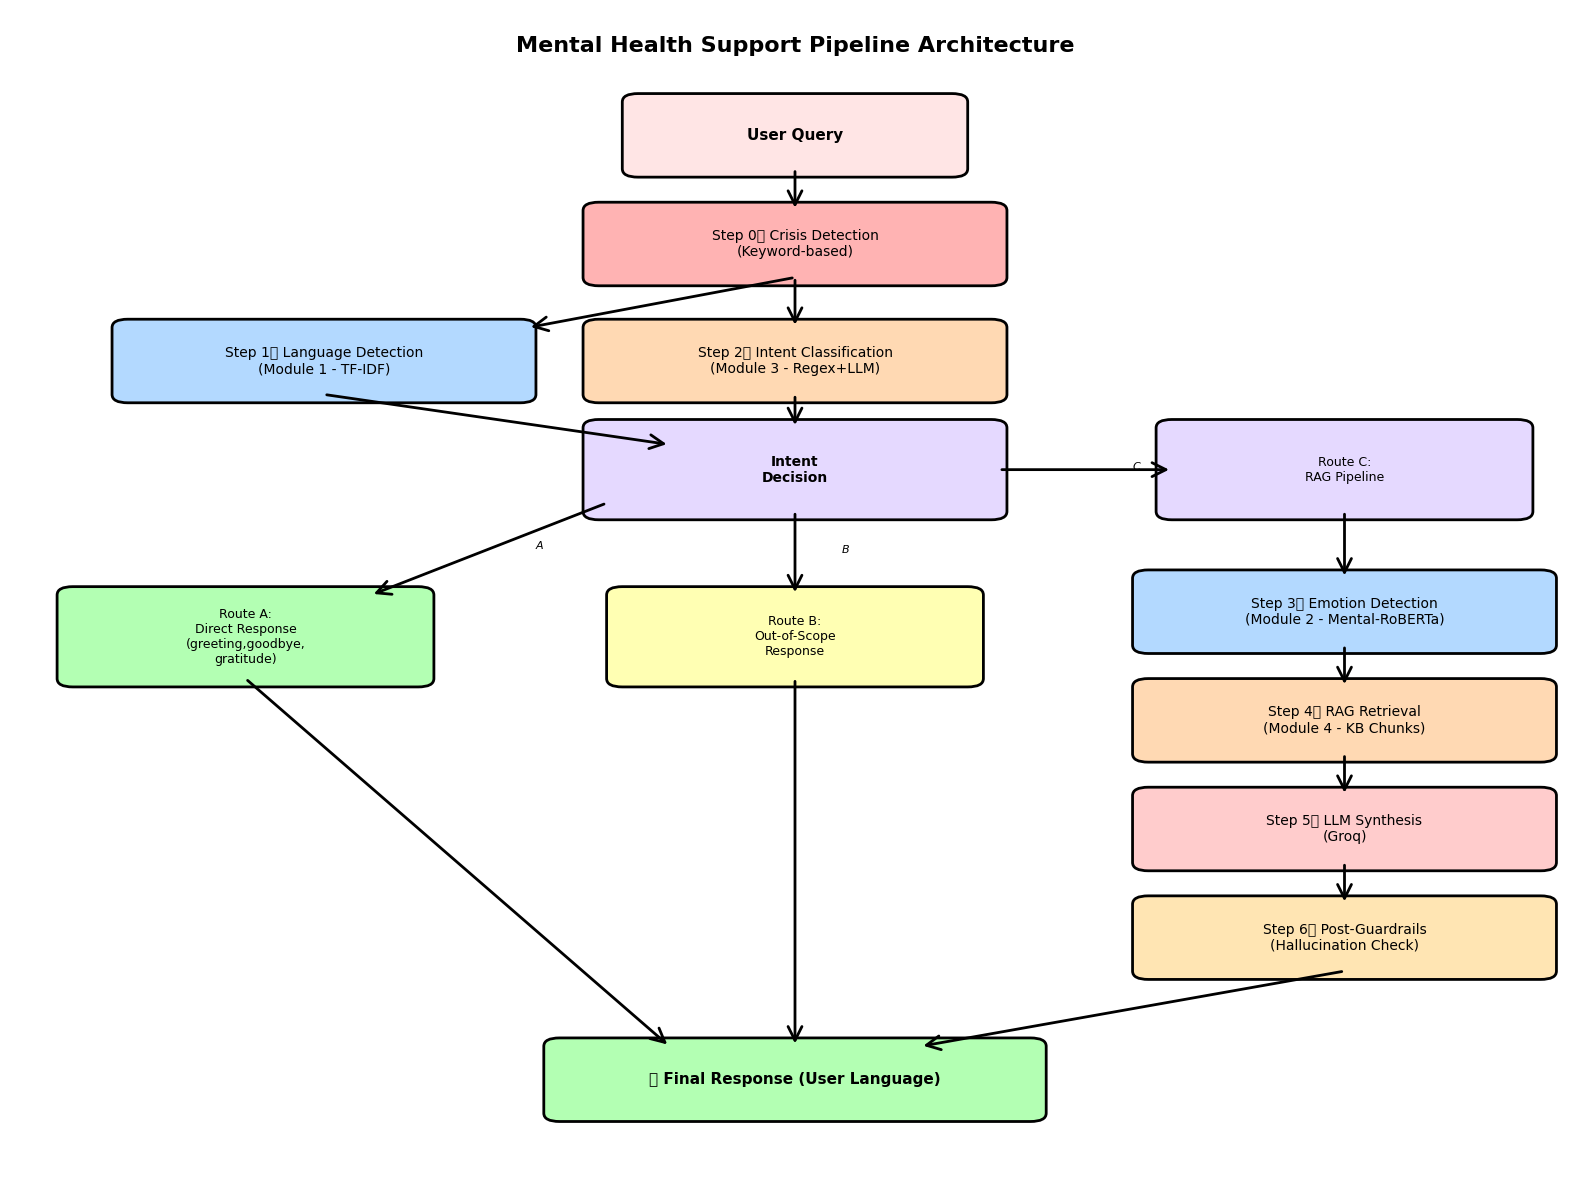

✅ Architecture diagram saved as 'pipeline_architecture.png'


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create architecture diagram
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

# Helper function to draw boxes
def draw_box(ax, x, y, width, height, text, color, fontsize=10, weight='normal'):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, 
            weight=weight, wrap=True, bbox=dict(boxstyle='round', facecolor='white', alpha=0))

# Helper function to draw arrows
def draw_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=25, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=8, style='italic')

# Title
ax.text(5, 13.5, 'Mental Health Support Pipeline Architecture', 
        fontsize=16, weight='bold', ha='center')

# User Input
draw_box(ax, 5, 12.5, 2, 0.8, 'User Query', '#FFE5E5', fontsize=11, weight='bold')

# Step 0: Crisis Detection
draw_box(ax, 5, 11.2, 2.5, 0.8, 'Step 0️⃣ Crisis Detection\n(Keyword-based)', '#FFB3B3', fontsize=10)
draw_arrow(ax, 5, 12.1, 5, 11.6)

# Step 1: Language Detection
draw_box(ax, 2, 9.8, 2.5, 0.8, 'Step 1️⃣ Language Detection\n(Module 1 - TF-IDF)', '#B3D9FF', fontsize=10)
draw_arrow(ax, 5, 10.8, 3.3, 10.2)

# Step 2: Intent Classification
draw_box(ax, 5, 9.8, 2.5, 0.8, 'Step 2️⃣ Intent Classification\n(Module 3 - Regex+LLM)', '#FFD9B3', fontsize=10)
draw_arrow(ax, 5, 10.8, 5, 10.2)

# Decision Diamond
draw_box(ax, 5, 8.5, 2.5, 1, 'Intent\nDecision', '#E5D9FF', fontsize=10, weight='bold')
draw_arrow(ax, 2, 9.4, 4.2, 8.8)
draw_arrow(ax, 5, 9.4, 5, 9)

# Route A: Direct (greeting/goodbye/gratitude)
draw_box(ax, 1.5, 6.5, 2.2, 1, 'Route A:\nDirect Response\n(greeting,goodbye,\ngratitude)', '#B3FFB3', fontsize=9)
draw_arrow(ax, 3.8, 8.1, 2.3, 7, 'A')

# Route B: Out-of-scope
draw_box(ax, 5, 6.5, 2.2, 1, 'Route B:\nOut-of-Scope\nResponse', '#FFFFB3', fontsize=9)
draw_arrow(ax, 5, 8, 5, 7, 'B')

# Route C: RAG Pipeline
draw_box(ax, 8.5, 8.5, 2.2, 1, 'Route C:\nRAG Pipeline', '#E5D9FF', fontsize=9)
draw_arrow(ax, 6.3, 8.5, 7.4, 8.5, 'C')

# Step 3: Emotion Detection (Route C)
draw_box(ax, 8.5, 6.8, 2.5, 0.8, 'Step 3️⃣ Emotion Detection\n(Module 2 - Mental-RoBERTa)', '#B3D9FF', fontsize=10)
draw_arrow(ax, 8.5, 8, 8.5, 7.2)

# Step 4: RAG Retrieval (Route C)
draw_box(ax, 8.5, 5.5, 2.5, 0.8, 'Step 4️⃣ RAG Retrieval\n(Module 4 - KB Chunks)', '#FFD9B3', fontsize=10)
draw_arrow(ax, 8.5, 6.4, 8.5, 5.9)

# Step 5: LLM Synthesis (Route C)
draw_box(ax, 8.5, 4.2, 2.5, 0.8, 'Step 5️⃣ LLM Synthesis\n(Groq)', '#FFCCCC', fontsize=10)
draw_arrow(ax, 8.5, 5.1, 8.5, 4.6)

# Step 6: Post-Guardrails (Route C)
draw_box(ax, 8.5, 2.9, 2.5, 0.8, 'Step 6️⃣ Post-Guardrails\n(Hallucination Check)', '#FFE5B3', fontsize=10)
draw_arrow(ax, 8.5, 3.8, 8.5, 3.3)

# Convergence: Final Response
draw_box(ax, 5, 1.2, 3, 0.8, '✅ Final Response (User Language)', '#B3FFB3', fontsize=11, weight='bold')
draw_arrow(ax, 1.5, 6, 4.2, 1.6)
draw_arrow(ax, 5, 6, 5, 1.6)
draw_arrow(ax, 8.5, 2.5, 5.8, 1.6)

plt.tight_layout()
plt.savefig('pipeline_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Architecture diagram saved as 'pipeline_architecture.png'")

## Section 16: Interactive Testing (Optional)

In [23]:
# Uncomment below to test with your own queries

# Interactive testing
while True:
    user_input = input("\nEnter your message (or 'quit' to exit): ")
    if user_input.lower() == 'quit':
        break
    
    result = pipeline(user_input, verbose=True)
    print(f"\n📊 Summary:")
    print(f"   Route: {result['route']}")
    print(f"   Response: {result['final_response'][:100]}...")


🔄 PIPELINE START | Input: 'اهلا بك'

Step 0️⃣  CRISIS DETECTION
        Status: ✅ Safe

Step 1️⃣  MODULE 1: LANGUAGE DETECTION
        Detected: en (97.8%)

Step 2️⃣  MODULE 3: INTENT CLASSIFICATION (Regex + LLM)
        Intent: greeting
        Layer used: Layer 2 (LLM)
        Confidence: 99.0%
        Translated: 'Hello...'

➡️  ROUTE: Direct Response (greeting)
   Response: مرحباً! أنا هنا لدعمك. كيف تشعر اليوم؟


📊 Summary:
   Route: direct
   Response: مرحباً! أنا هنا لدعمك. كيف تشعر اليوم؟...

🔄 PIPELINE START | Input: 'انا اشعر بالخوف الشديد'

Step 0️⃣  CRISIS DETECTION
        Status: ✅ Safe

Step 1️⃣  MODULE 1: LANGUAGE DETECTION
        Detected: en (99.3%)

Step 2️⃣  MODULE 3: INTENT CLASSIFICATION (Regex + LLM)
        Intent: asking_mental_health_question
        Layer used: Layer 2 (LLM)
        Confidence: 98.0%
        Translated: 'I feel very afraid...'

➡️  ROUTE: Mental Health Question (Full RAG Pipeline)

Step 3️⃣  MODULE 2: EMOTION DETECTION
        Emotion: fear